In [ ]:
import pandas as pd
import seaborn as sns
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
df = pd.read_csv("smartcart_customers.csv")

# Handle missing values

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature engineering

In [4]:
# Customer Tenure
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer Tenure"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

In [5]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [6]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "2n Cycle": "Undergraduate", "Basic": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "PostGraduate", "PhD": "PostGraduate"
})

In [7]:
# Living with
df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone", "Widow": "Alone",
    "Absurd": "Alone", "YOLO": "Alone"
})

In [8]:
# Total children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Total spendings
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

## Drop columns

In [9]:
cols_to_drop = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df_cleaned = df.drop(columns=cols_to_drop)

## Outliers detection

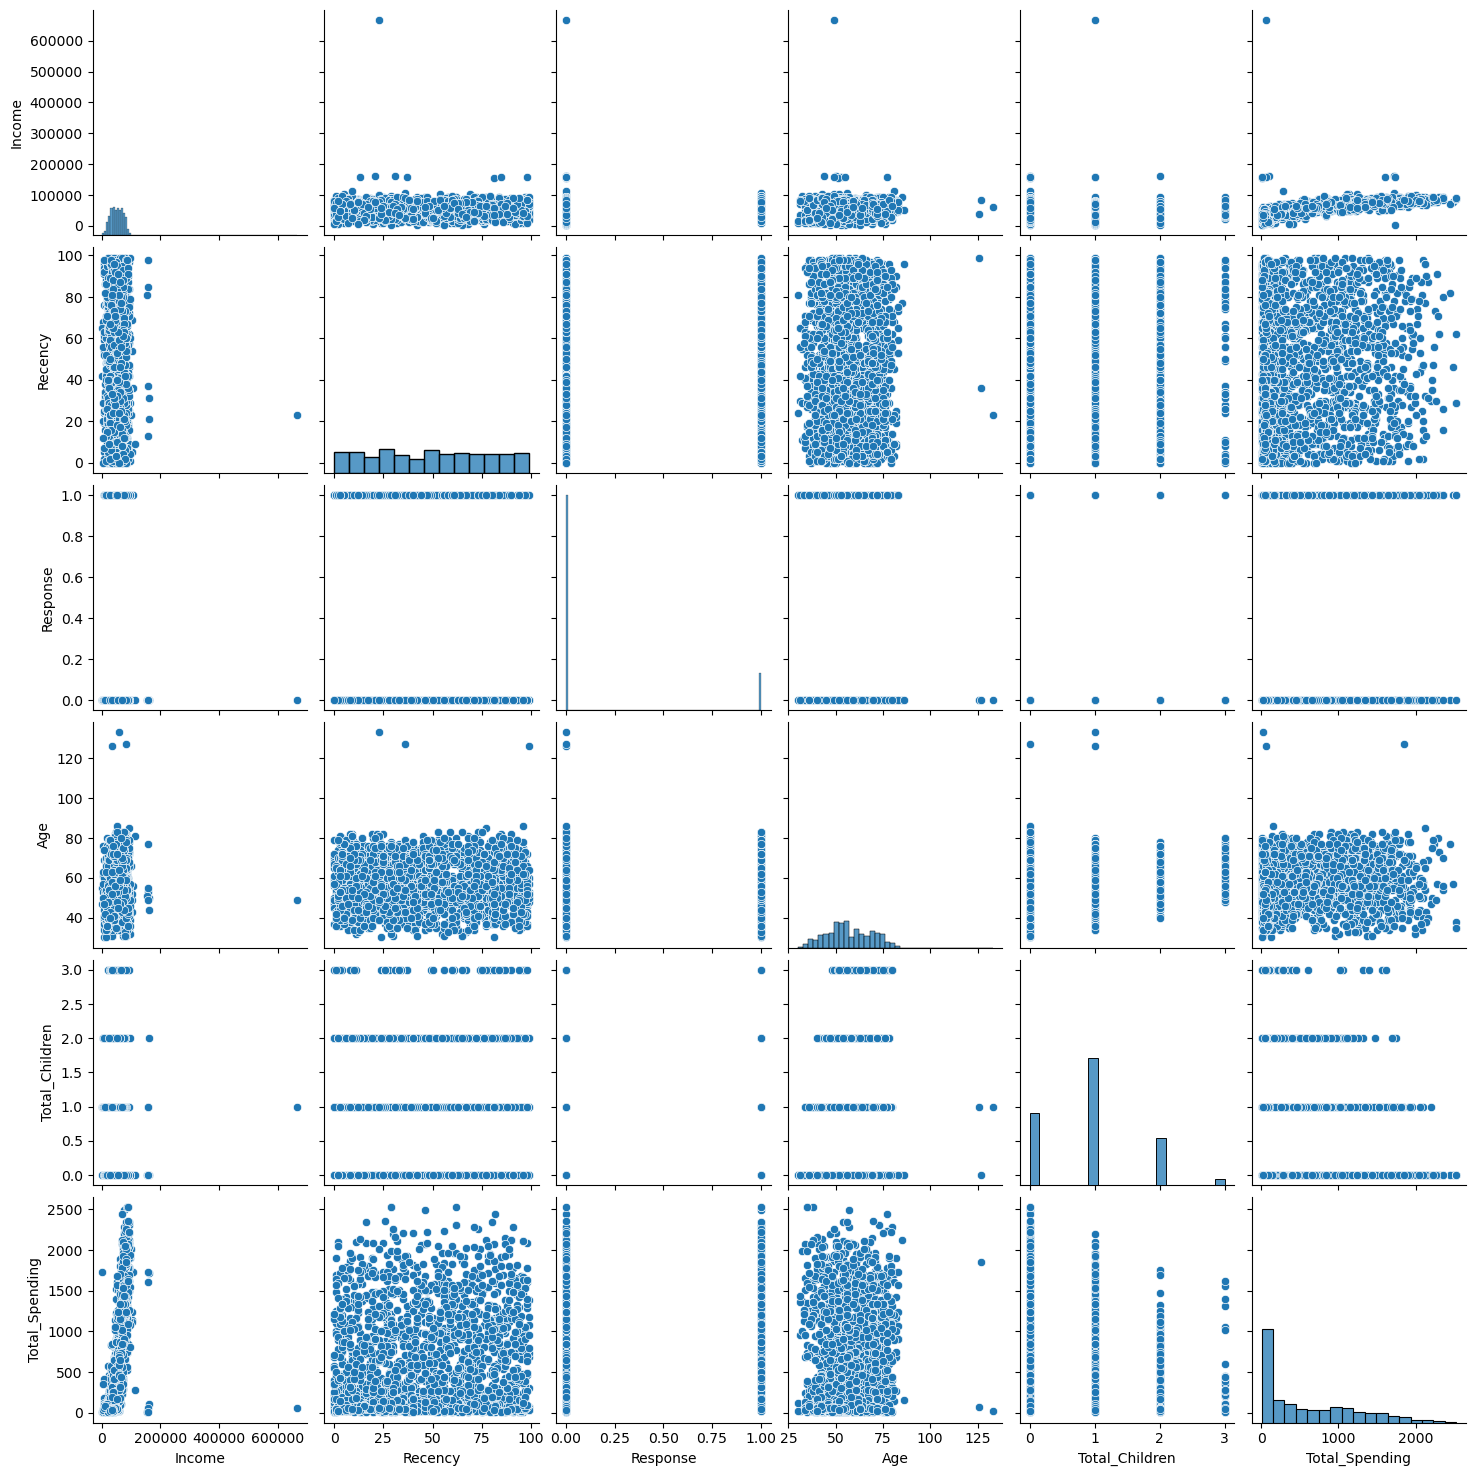

In [10]:
cols = ["Income", "Recency", "Response", "Age", "Total_Children", "Total_Spending"]

sns.pairplot(df_cleaned[cols])

In [11]:
print("Data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"]<90]
df_cleaned = df_cleaned[df_cleaned["Income"]<600_000]

print("Data size without outliers:", len(df_cleaned))

Data size with outliers: 2240
Data size without outliers: 2236


# Heatmap

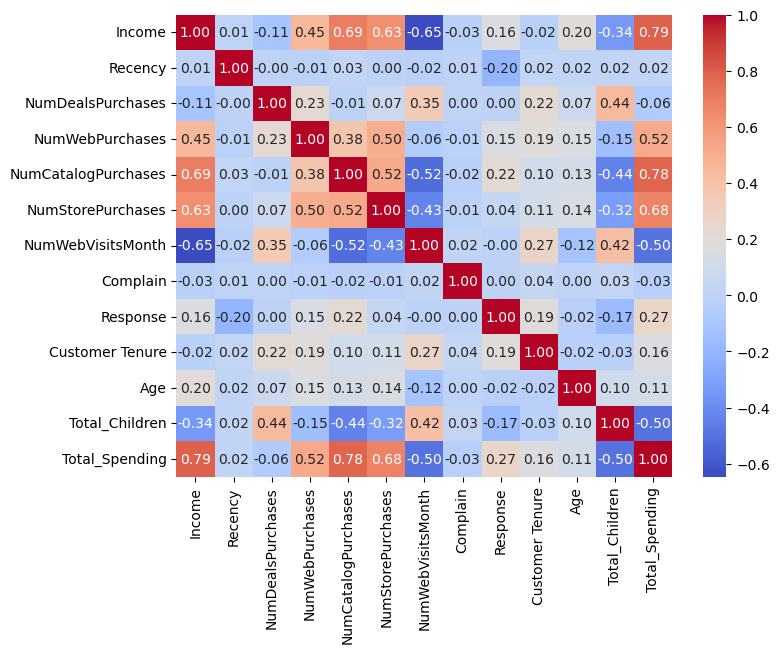

In [12]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# Encoding

In [13]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(), index=df_cleaned.index)

df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

# Scaling

In [14]:
X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA - Visualisation

Text(0.5, 1.0, 'PCA Visualisation')

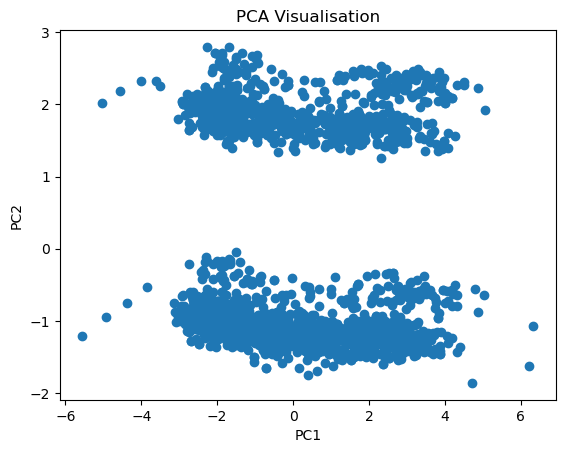

In [15]:
# 2D Visualisation
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

plt.scatter(x=X_pca_2d[:,0], y=X_pca_2d[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualisation")

Text(0.5, 0.92, 'PCA Visualisation')

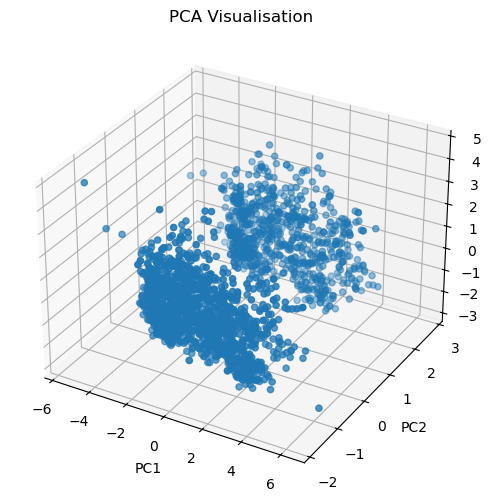

In [16]:
# 3D Visualisation
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Visualisation")

# Finding out optimal K

## 1. Elbow method

In [17]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)

In [18]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
print(knee.knee)

4


<Axes: >

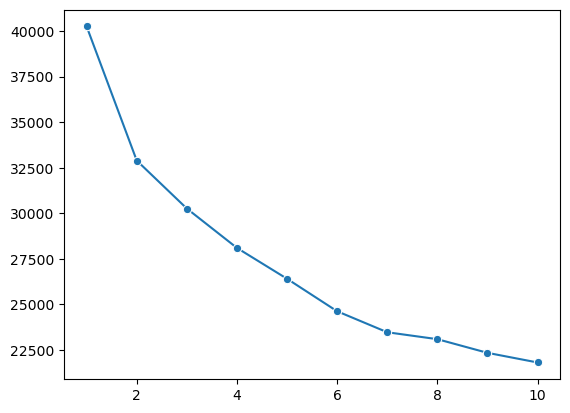

In [19]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

## 2. Silhouette score

In [20]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    label = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, label)
    scores.append(score)

<Axes: >

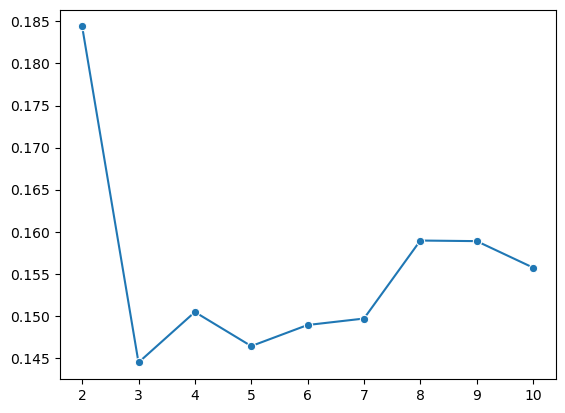

In [21]:
sns.lineplot(x=range(2,11), y=scores, marker='o')

## Combined plot analysis

Text(0, 0.5, 'Silhouette scores')

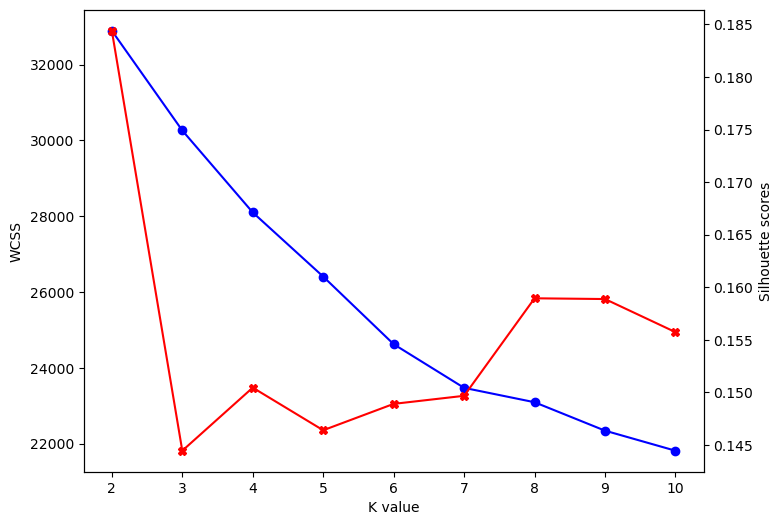

In [22]:
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(range(2, 11), wcss[1:], color='blue', marker='o')
ax1.set_xlabel("K value")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(range(2,11), scores, color='red', marker='X')
ax2.set_ylabel("Silhouette scores")

# KMeans

Text(0.5, 0.92, 'PCA Visualisation')

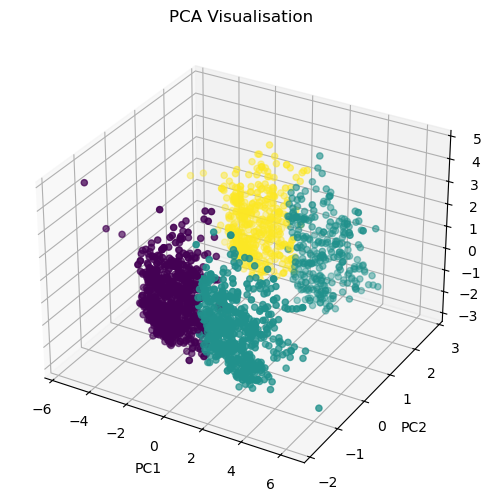

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], c=kmeans_labels)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Visualisation")

# Agglomerative clustering

Text(0.5, 0.92, 'PCA Visualisation')

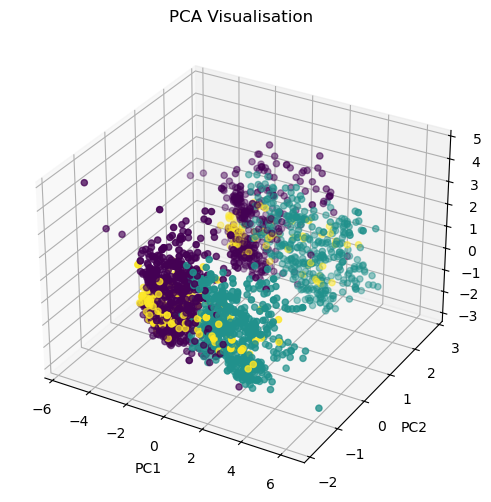

In [24]:
agg_clf = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg_clf.fit_predict(X_scaled)


fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], c=agg_labels)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Visualisation")

In [25]:
print(silhouette_score(X_scaled, kmeans_labels))
print(silhouette_score(X_scaled, agg_labels))

0.14446424987639694
0.15611720288479514


### Model Comparison

K-Means and Agglomerative Clustering were evaluated on the
standardised feature space using the Silhouette Score.

- K-Means: 0.1401
- Agglomerative Clustering: 0.1561

Agglomerative Clustering achieved a slightly higher Silhouette Score,
indicating a somewhat better-defined cluster structure for this
feature representation. Therefore, Agglomerative Clustering was
selected for the final customer segmentation.

# Characterization of clusters

<Axes: xlabel='Clusters', ylabel='count'>

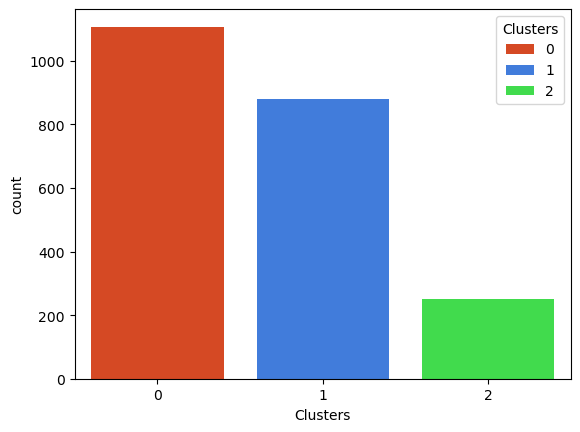

In [26]:
X["Clusters"] = agg_labels

cpal = ["#F23807", "#2776F5", "#27F538"]
sns.countplot(x=X["Clusters"], palette=cpal, hue=X["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

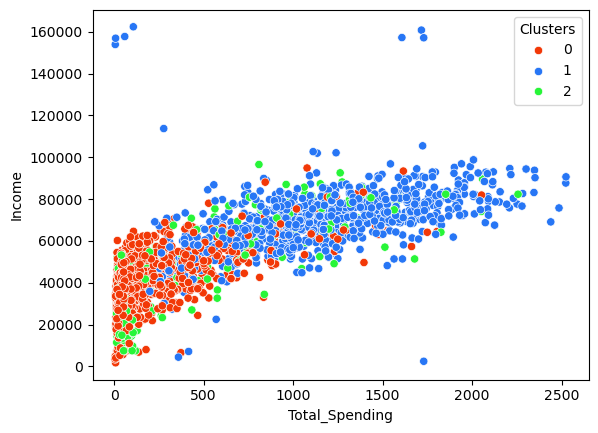

In [27]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["Clusters"], palette=cpal)

In [28]:
cluster_summary = X.groupby(X["Clusters"]).mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39748.051942  49.555556           2.636856         3.021680   
1         70236.518771  48.767918           2.006826         5.640501   
2         41708.206000  48.396000           2.072000         3.348000   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    1.037940           3.962963           6.441734  0.018067   
1                    4.923777           8.354949           3.782708  0.000000   
2                    1.912000           4.912000           5.748000  0.000000   

          Response  Customer Tenure        Age  Total_Children  \
Clusters                                                         
0         0.141825       344.166215  56.614273        1.289070   
1         0.175199       360.2

# Inference

## Cluster Characterisation & Business Interpretation

### Cluster 0 — Lower-Spending, Higher-Visit Customers

**Cluster Characterisation**
- Lower income and the lowest overall spending
- Highest website visits among the three clusters
- Lower web, catalog and store purchase activity
- Higher average number of children

**Business Interpretation**
- Customers show relatively high website engagement but limited purchasing activity.
- Targeted promotions and personalised recommendations could potentially improve conversion.

---

### Cluster 1 — High-Value Customers

**Cluster Characterisation**
- Highest income and significantly higher overall spending
- Highest web, catalog and store purchase activity
- Lower website visits compared with other clusters
- Lower average number of children

**Business Interpretation**
- Customers demonstrate strong purchasing value across multiple channels.
- Loyalty-focused initiatives and personalised recommendations could potentially be considered for this segment.

---

### Cluster 2 — Moderate-Spending Customers

**Cluster Characterisation**
- Moderate income and spending
- Higher store purchase activity than Cluster 0
- Moderate website engagement
- Lower campaign response compared with the other clusters

**Business Interpretation**
- Customers demonstrate moderate purchasing activity but relatively lower response.
- Targeted engagement strategies could potentially be explored to improve customer response and retention.

# Conclusion

The SmartCart Clustering System used exploratory data analysis, feature
engineering, categorical encoding and feature scaling to prepare customer
data for unsupervised learning.

K-Means and Agglomerative Clustering were evaluated using the Silhouette
Score, with Agglomerative Clustering producing the better-defined cluster
structure for the selected feature space.

The final model identified three distinct customer segments based on
income, spending behaviour, purchase activity, website engagement and
household characteristics. These segments provide useful insights that
could support differentiated customer engagement and marketing strategies.

In [30]:
import joblib
import os
import numpy as np

os.makedirs("models", exist_ok=True)

# Original ML features only — exclude Clusters
feature_columns = [
    col for col in X.columns
    if col != "Clusters"
]

# Calculate centre of each Agglomerative cluster
cluster_centers = np.array([
    X_scaled[agg_labels == cluster].mean(axis=0)
    for cluster in sorted(np.unique(agg_labels))
])

joblib.dump(
    {
        "scaler": scaler,
        "feature_columns": feature_columns,
        "cluster_centers": cluster_centers,
        "cluster_labels": sorted(np.unique(agg_labels).tolist())
    },
    "models/smartcart_model.pkl"
)

print("SmartCart model artifacts saved successfully!")
print("Number of features:", len(feature_columns))

SmartCart model artifacts saved successfully!
Number of features: 18


In [32]:
import numpy as np
import pandas as pd

feature_columns = [
    col for col in X.columns
    if col != "Clusters"
]

clusters = sorted(np.unique(agg_labels))

for cluster in clusters:
    center = X_scaled[agg_labels == cluster].mean(axis=0)

    center_original = scaler.inverse_transform([center])[0]

    print(f"\nCluster {cluster}")
    print(
        pd.Series(
            center_original,
            index=feature_columns
        )
    )


Cluster 0
Income                     39748.051942
Recency                       49.555556
NumDealsPurchases              2.636856
NumWebPurchases                3.021680
NumCatalogPurchases            1.037940
NumStorePurchases              3.962963
NumWebVisitsMonth              6.441734
Complain                       0.018067
Response                       0.141825
Customer Tenure              344.166215
Age                           56.614273
Total_Children                 1.289070
Total_Spending               217.061427
Education_Graduate             0.541102
Education_PostGraduate         0.454381
Education_Undergraduate        0.004517
Living_With_Alone              0.314363
Living_With_Partner            0.685637
dtype: float64

Cluster 1
Income                     7.023652e+04
Recency                    4.876792e+01
NumDealsPurchases          2.006826e+00
NumWebPurchases            5.640501e+00
NumCatalogPurchases        4.923777e+00
NumStorePurchases          8.354949e+00
Num